# Customer Churn Prediction - Notebook

Steps covered:
1. Data Preparation
2. EDA
3. Feature Engineering
4. Model Building
5. Final Test Performance
6. Model Interpretation
7. Model Saving + API

## Step 1: Data Preparation

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

In [8]:
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

print("Shape:", df.shape)
display(df.head(3))
display(df.info())

print("\nTarget counts:")
print(df["Churn"].value_counts())

print("\nTarget percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None


Target counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 20)
Target shape: (7043,)


In [10]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3944, 20)
Validation: (986, 20)
Test: (2113, 20)


In [5]:
df_check = df.copy()

print("Dataset shape:", df_check.shape)
print("Total columns:", len(df_check.columns))
print("Columns list:")
print(df_check.columns.tolist())

Dataset shape: (7043, 21)
Total columns: 21
Columns list:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
missing_counts = df_check.isna().sum()
missing_pct = (missing_counts / len(df_check) * 100).round(3)

missing_table = pd.DataFrame({
"missing_count": missing_counts,
"missing_percent": missing_pct
}).sort_values("missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [8]:
blank_counts = {}

for col in df_check.columns:
    blank_counts[col] = (df_check[col].astype(str).str.strip() == "").sum()

blank_table = pd.DataFrame({
    "blank_count": pd.Series(blank_counts)
}).sort_values("blank_count", ascending=False)

display(blank_table[blank_table["blank_count"] > 0])

,blank_count
TotalCharges,11


In [9]:
duplicate_rows = df_check.duplicated().sum()
duplicate_ids = df_check["customerID"].duplicated().sum()

print("Duplicate full rows:", duplicate_rows)
print("Duplicate customerID:", duplicate_ids)

Duplicate full rows: 0
Duplicate customerID: 0


In [10]:
dtype_table = pd.DataFrame({
    "column": df_check.columns,
    "dtype": df_check.dtypes.astype(str).values
})

display(dtype_table)

print("Target distribution:")
print(df_check["Churn"].value_counts())
print((df_check["Churn"].value_counts(normalize=True) * 100).round(2))

,column,dtype
0,customerID,str
1,gender,str
2,SeniorCitizen,int64
3,Partner,str
4,Dependents,str
5,tenure,int64
6,PhoneService,str
7,MultipleLines,str
8,InternetService,str
9,OnlineSecurity,str


Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [11]:
df_check["TotalCharges"] = pd.to_numeric(df_check["TotalCharges"], errors="coerce")

print("TotalCharges dtype:", df_check["TotalCharges"].dtype)
print("TotalCharges missing after conversion:", df_check["TotalCharges"].isna().sum())

TotalCharges dtype: float64
TotalCharges missing after conversion: 11


In [12]:
target_col = "Churn"

feature_cols = [c for c in df_check.columns if c != target_col]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_check[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Feature columns:", len(feature_cols))
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Feature columns: 20
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Step 2: EDA

In [13]:
eda_df = df.copy()

eda_df["TotalCharges"] = pd.to_numeric(eda_df["TotalCharges"], errors="coerce")

print("EDA shape:", eda_df.shape)
print("Missing TotalCharges:", eda_df["TotalCharges"].isna().sum())

EDA shape: (7043, 21)
Missing TotalCharges: 11


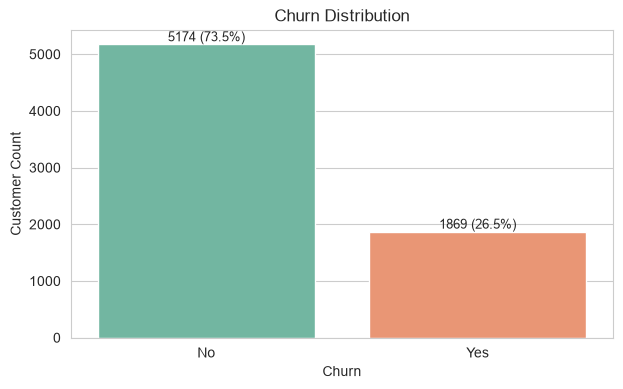

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=eda_df, x="Churn", hue="Churn", palette="Set2", legend=False)

total = len(eda_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = (count / total) * 100
    ax.annotate(
        f"{count} ({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


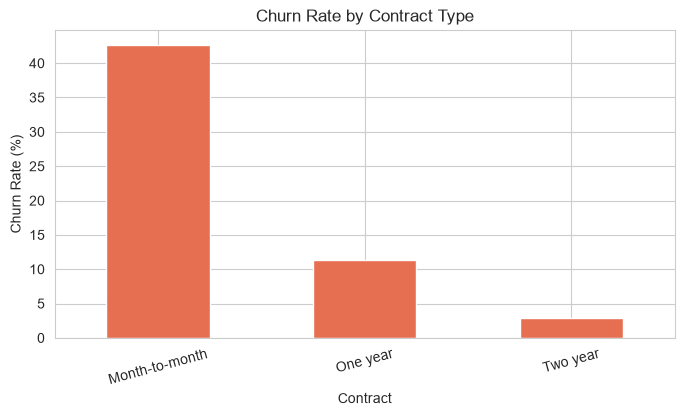

In [15]:
contract_churn = pd.crosstab(
    eda_df["Contract"],
    eda_df["Churn"],
    normalize="index"
) * 100

display(contract_churn.round(2))

contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 4),
    color="#e76f51"
)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

Month-to-month customers show the highest churn risk (42.71%), while two-year customers show the lowest churn risk (2.83%), indicating contract length is strongly linked to retention.

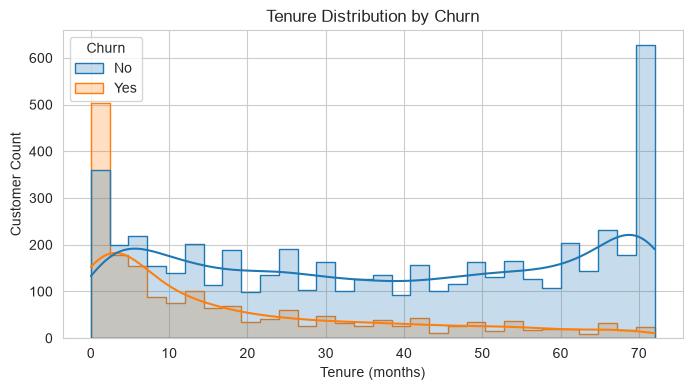

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=eda_df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Customer Count")
plt.show()

Churn is concentrated in lower-tenure customers.

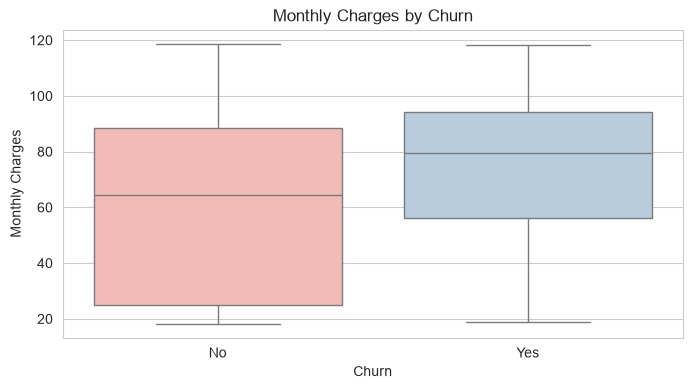

Median MonthlyCharges by Churn:
Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Pastel1",
    legend=False
)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

print("Median MonthlyCharges by Churn:")
print(eda_df.groupby("Churn", observed=False)["MonthlyCharges"].median())

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


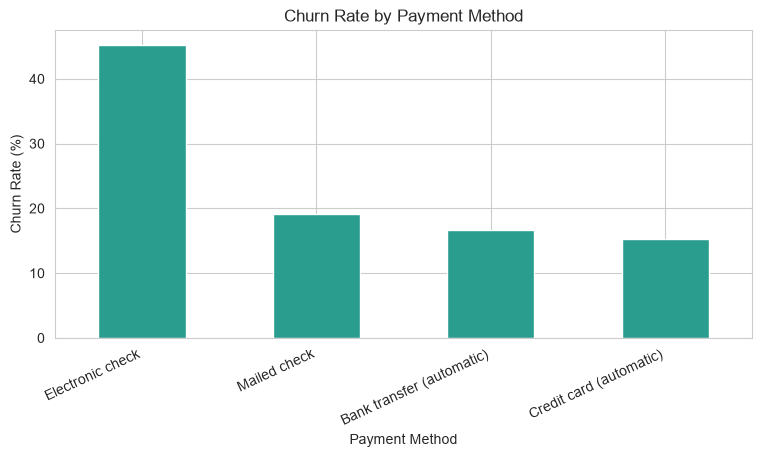

In [21]:
payment_churn = pd.crosstab(
    eda_df["PaymentMethod"],
    eda_df["Churn"],
    normalize="index"
) * 100

display(payment_churn.round(2))

payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 4),
    color="#2a9d8f"
)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.show()

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


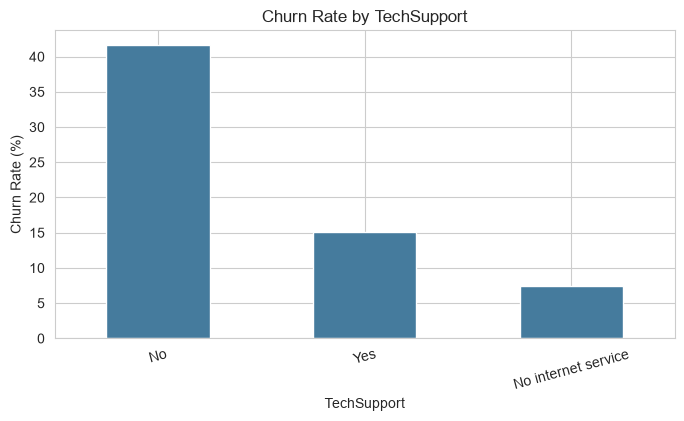

In [22]:
tech_churn = pd.crosstab(
    eda_df["TechSupport"],
    eda_df["Churn"],
    normalize="index"
) * 100

display(tech_churn.round(2))

tech_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 4),
    color="#457b9d"
)
plt.title("Churn Rate by TechSupport")
plt.xlabel("TechSupport")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

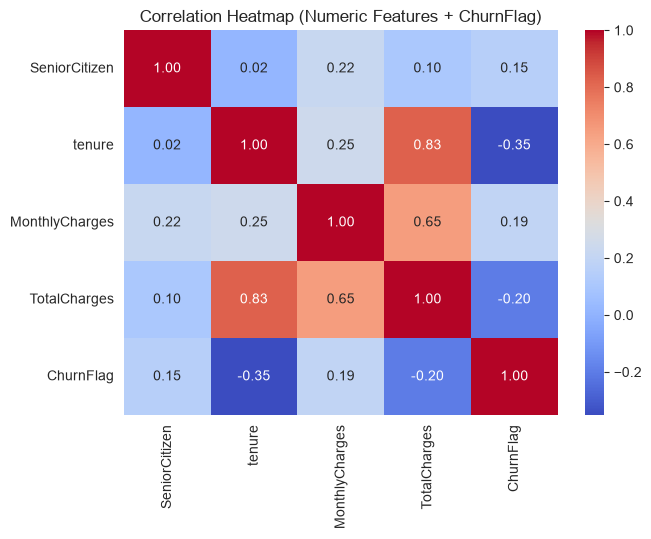

In [23]:
corr_df = eda_df.copy()
corr_df["ChurnFlag"] = corr_df["Churn"].map({"No": 0, "Yes": 1})

num_cols_for_corr = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
corr_matrix = corr_df[num_cols_for_corr].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features + ChurnFlag)")
plt.show()

## Step 2: EDA Summary

From the plots, a few patterns stood out clearly:

1. Churn is imbalanced (more No than Yes).
2. Month-to-month contract customers have the highest churn risk.
3. Lower-tenure customers are more likely to churn.
4. Higher monthly charges are often linked with churn.
5. Payment method and tech support also show visible churn differences.

Business takeaways from EDA:
- Month-to-month customers are high risk compared to long-term contract customers.
- Churn appears more concentrated among lower-tenure customers.

## Step 3: Feature Engineering

In [24]:
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

print("Train shape before FE:", X_train_fe.shape)
print("Validation shape before FE:", X_val_fe.shape)
print("Test shape before FE:", X_test_fe.shape)

Train shape before FE: (3944, 20)
Validation shape before FE: (986, 20)
Test shape before FE: (2113, 20)


In [ ]:
def add_features(input_df):
    df_temp = input_df.copy()

    # Ensure TotalCharges is numeric
    df_temp["TotalCharges"] = pd.to_numeric(df_temp["TotalCharges"], errors="coerce")

    # Temporary fill only for stable feature calculations
    df_temp["TotalCharges"] = df_temp["TotalCharges"].fillna(0)

    # Feature 1: Number of active services
    service_cols = [
        "PhoneService",
        "MultipleLines",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    for col in service_cols:
        df_temp[col] = df_temp[col].astype(str)

    df_temp["NumServices"] = 0
    df_temp["NumServices"] += (df_temp["PhoneService"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["MultipleLines"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["OnlineSecurity"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["OnlineBackup"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["DeviceProtection"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["TechSupport"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["StreamingTV"] == "Yes").astype(int)
    df_temp["NumServices"] += (df_temp["StreamingMovies"] == "Yes").astype(int)

    # Feature 2: Average charges per month
    tenure_safe = df_temp["tenure"].replace(0, 1)
    df_temp["AvgChargesPerMonth"] = df_temp["TotalCharges"] / tenure_safe

    # feature 3: New customer flag
    df_temp["IsNewCustomer"] = (df_temp["tenure"] <= 12).astype(int)

    return df_temp

In [26]:
# Apply same feature logic to all splits
X_train_fe = add_features(X_train_fe)
X_val_fe = add_features(X_val_fe)
X_test_fe = add_features(X_test_fe)

print("Train shape after FE:", X_train_fe.shape)
print("Validation shape after FE:", X_val_fe.shape)
print("Test shape after FE:", X_test_fe.shape)
print("\nNew columns added:", ["NumServices", "AvgChargesPerMonth", "IsNewCustomer"])

Train shape after FE: (3944, 23)
Validation shape after FE: (986, 23)
Test shape after FE: (2113, 23)

New columns added: ['NumServices', 'AvgChargesPerMonth', 'IsNewCustomer']


In [27]:
# Quick sanity check
display(
    X_train_fe[
        ["tenure", "MonthlyCharges", "TotalCharges", "NumServices", "AvgChargesPerMonth", "IsNewCustomer"]
    ].head(10)
)

print("NumServices min/max:", X_train_fe["NumServices"].min(), X_train_fe["NumServices"].max())
print("AvgChargesPerMonth min/max:", X_train_fe["AvgChargesPerMonth"].min(), X_train_fe["AvgChargesPerMonth"].max())
print("IsNewCustomer counts:")
print(X_train_fe["IsNewCustomer"].value_counts())

,tenure,MonthlyCharges,TotalCharges,NumServices,AvgChargesPerMonth,IsNewCustomer
6857,58,92.85,5305.05,4,91.466379,0
6536,1,24.40,24.40,0,24.400000,1
3526,5,50.35,237.25,2,47.450000,1
3168,50,19.35,1033.00,1,20.660000,0
3923,1,80.85,80.85,2,80.850000,1
5813,48,111.80,5443.65,8,113.409375,0
6741,12,96.00,1062.10,4,88.508333,1
1426,71,92.00,6585.20,6,92.749296,0
6818,3,71.10,213.35,5,71.116667,1
1122,19,44.85,893.55,2,47.028947,0


NumServices min/max: 0 8
AvgChargesPerMonth min/max: 0.0 121.4
IsNewCustomer counts:
IsNewCustomer
0    2746
1    1198
Name: count, dtype: int64


In [28]:
# Feature usefulness check on training data only
train_analysis = X_train_fe.copy()
train_analysis["Churn"] = y_train.values

print("Churn % by IsNewCustomer:")
print((pd.crosstab(train_analysis["IsNewCustomer"], train_analysis["Churn"], normalize="index") * 100).round(2))

print("\nAverage NumServices by Churn:")
print(train_analysis.groupby("Churn")["NumServices"].mean().round(2))

print("\nAverage AvgChargesPerMonth by Churn:")
print(train_analysis.groupby("Churn")["AvgChargesPerMonth"].mean().round(2))

Churn % by IsNewCustomer:
Churn             No    Yes
IsNewCustomer              
0              83.18  16.82
1              51.25  48.75

Average NumServices by Churn:
Churn
No     3.46
Yes    3.16
Name: NumServices, dtype: float64

Average AvgChargesPerMonth by Churn:
Churn
No     61.03
Yes    74.83
Name: AvgChargesPerMonth, dtype: float64


## Step 3: Feature Engineering Summary

In this step, I created three practical features:

1. NumServices from active service subscriptions.
2. AvgChargesPerMonth as TotalCharges divided by tenure.
3. IsNewCustomer (tenure <= 12) as a bonus flag.

I applied the same transformation to train, validation, and test data to keep the workflow consistent and avoid leakage.

Features details:

1. NumServices
- How I created it: counted how many services are active ('Yes') across service columns like PhoneService, OnlineSecurity, StreamingTV, etc.
- Why it helps: this gives a single engagement score. Customers using fewer services often have lower switching cost and can be more likely to churn.

2. AvgChargesPerMonth
- How I created it: divided 'TotalCharges' by 'tenure' (with safe handling for zero tenure).
- Why it helps: this normalizes billing by customer age and gives a better view of effective monthly burden.

3. IsNewCustomer
- How I created it: set value to 1 if tenure is 12 months or less, else 0.
- Why it helps: early lifecycle customers usually churn more, so this feature captures that behavior directly.

## Step 4: Model Building

In [5]:
# Prepare model-ready datasets
X_train_model = X_train_fe.drop(columns=["customerID"]).copy()
X_val_model = X_val_fe.drop(columns=["customerID"]).copy()
X_test_model = X_test_fe.drop(columns=["customerID"]).copy()

print("Train model shape:", X_train_model.shape)
print("Validation model shape:", X_val_model.shape)
print("Test model shape:", X_test_model.shape)

Train model shape: (3944, 22)
Validation model shape: (986, 22)
Test model shape: (2113, 22)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Detect column groups from training data only
num_cols_model = X_train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_model = X_train_model.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", num_cols_model)
print("Categorical columns:", cat_cols_model)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_model),
        ("cat", categorical_transformer, cat_cols_model)
    ]
)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgChargesPerMonth', 'IsNewCustomer']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Two Decision Tree configurations

model_configs = {
    "DT_Config_A_Shallow": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=40,
        class_weight="balanced",
        random_state=42
    ),
    "DT_Config_B_Deeper": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )
}

In [ ]:
# Train and evaluate both configurations on validation set
results = []
trained_pipelines = {}

for model_name, dt_model in model_configs.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", dt_model)
    ])

    pipe.fit(X_train_model, y_train)
    val_pred = pipe.predict(X_val_model)

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred, pos_label="Yes", zero_division=0),
        "Recall": recall_score(y_val, val_pred, pos_label="Yes", zero_division=0),
        "F1": f1_score(y_val, val_pred, pos_label="Yes", zero_division=0)
    }

    results.append(row)
    trained_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by=["Recall", "F1"], ascending=False)
print(results_df)

[{'Model': 'DT_Config_A_Shallow', 'Accuracy': 0.735294, 'Precision': 0.501241, 'Recall': 0.770992, 'F1': 0.607519}, {'Model': 'DT_Config_B_Deeper', 'Accuracy': 0.709939, 'Precision': 0.471963, 'Recall': 0.770992, 'F1': 0.585507}]

## Step 4: Model Building Summary

trained two Decision Tree configurations and compared both on validation data.

selected the better one based on recall first (business priority for churn), then checked F1 as a balance metric.

compared two manual Decision Tree configurations on the validation set. Both gave similar recall, but the shallow model had better precision, F1, and accuracy, so kept it as the initial best model.

## Hyperparameter Tuning (Grid Search)

compared two handpicked Decision Tree settings.
Then ran a small grid search around those values to verify whether a better configuration exists.

In [36]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [37]:
# Base pipeline for tuning
tune_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

In [38]:
# Small and practical search space
param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [10, 20, 40],
    "model__min_samples_split": [2, 10],
    "model__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
# Tune for recall-focused objective
grid = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_model, y_train)

print("Best CV score (recall_macro):", round(grid.best_score_, 4))
print("Best parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV score (recall_macro): 0.7573
Best parameters:
{'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}


In [40]:
# Top parameter combinations
cv_results = pd.DataFrame(grid.cv_results_)
show_cols = [
    "mean_test_score",
    "std_test_score",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__min_samples_split",
    "param_model__criterion"
]

top_results = cv_results[show_cols].sort_values("mean_test_score", ascending=False).head(10)
display(top_results)

,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split,param_model__criterion
0,0.757327,0.013005,4,10,2,gini
1,0.757327,0.013005,4,10,10,gini
2,0.757327,0.013005,4,20,2,gini
3,0.757327,0.013005,4,20,10,gini
19,0.756519,0.012847,4,10,10,entropy
18,0.756519,0.012847,4,10,2,entropy
21,0.756519,0.012847,4,20,10,entropy
20,0.756519,0.012847,4,20,2,entropy
4,0.756446,0.009934,4,40,2,gini
5,0.756446,0.009934,4,40,10,gini


In [41]:
# Evaluate tuned best model on validation set
best_tuned_model = grid.best_estimator_

val_pred_tuned = best_tuned_model.predict(X_val_model)

val_acc_tuned = accuracy_score(y_val, val_pred_tuned)
val_prec_tuned = precision_score(y_val, val_pred_tuned, pos_label="Yes", zero_division=0)
val_rec_tuned = recall_score(y_val, val_pred_tuned, pos_label="Yes", zero_division=0)
val_f1_tuned = f1_score(y_val, val_pred_tuned, pos_label="Yes", zero_division=0)

print("Tuned Validation Accuracy :", round(val_acc_tuned, 4))
print("Tuned Validation Precision:", round(val_prec_tuned, 4))
print("Tuned Validation Recall   :", round(val_rec_tuned, 4))
print("Tuned Validation F1       :", round(val_f1_tuned, 4))

Tuned Validation Accuracy : 0.7353
Tuned Validation Precision: 0.5012
Tuned Validation Recall   : 0.7786
Tuned Validation F1       : 0.6099


In [43]:
# Compare manual best vs tuned best
comparison_df = pd.DataFrame([
    {
        "Model": "Manual Best",
        "Accuracy": 0.735294,
        "Precision": 0.501241,
        "Recall": 0.770992,
        "F1": 0.607519
    },
    {
        "Model": "GridSearch Best",
        "Accuracy": val_acc_tuned,
        "Precision": val_prec_tuned,
        "Recall": val_rec_tuned,
        "F1": val_f1_tuned
    }
])

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1
0,Manual Best,0.735294,0.501241,0.770992,0.607519
1,GridSearch Best,0.735294,0.501229,0.778626,0.609865


selected the GridSearch-tuned model as final because it gave slightly better recall and F1 while keeping accuracy almost the same.

Here recall matters more because missing real churners is usually costlier than reaching a few extra non-churn customers.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
# selected GridSearch model
final_model = best_tuned_model

print("Final model ready for test evaluation.")

Final model ready for test evaluation.


In [46]:
# Predict on completely unseen test set
y_test_pred = final_model.predict(X_test_model)

# Probability for churn = "Yes"
class_order = list(final_model.named_steps["model"].classes_)
yes_index = class_order.index("Yes")
y_test_proba_yes = final_model.predict_proba(X_test_model)[:, yes_index]

print("Class order in model:", class_order)
print("Sample churn probabilities:", y_test_proba_yes[:5])

Class order in model: ['No', 'Yes']
Sample churn probabilities: [0.70623887 0.0406813  0.70623887 0.0406813  0.0406813 ]


In [47]:
# Core evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label="Yes", zero_division=0)
test_recall = recall_score(y_test, y_test_pred, pos_label="Yes", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, pos_label="Yes", zero_division=0)

print("Test Accuracy :", round(test_accuracy, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall   :", round(test_recall, 4))
print("Test F1 Score :", round(test_f1, 4))

Test Accuracy : 0.7539
Test Precision: 0.5255
Test Recall   : 0.754
Test F1 Score : 0.6193


In [48]:
# Detailed class-wise report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.75      0.82      1552
         Yes       0.53      0.75      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.80      0.75      0.77      2113



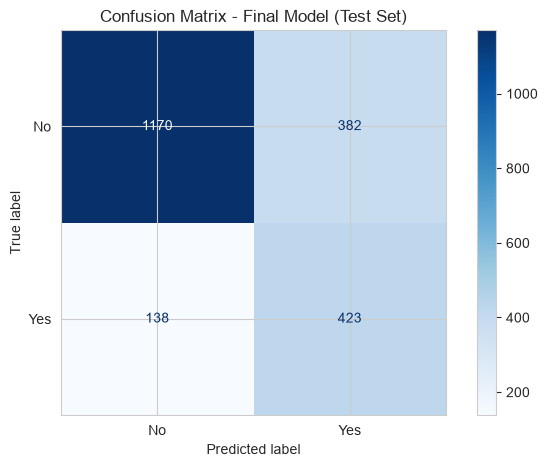

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=["No", "Yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Final Model (Test Set)")
plt.show()

In [50]:
# Put all final metrics in a clean table
eval_df = pd.DataFrame([
    {"Metric": "Accuracy", "Value": test_accuracy},
    {"Metric": "Precision", "Value": test_precision},
    {"Metric": "Recall", "Value": test_recall},
    {"Metric": "F1 Score", "Value": test_f1}
])

display(eval_df)

,Metric,Value
0,Accuracy,0.753904
1,Precision,0.525466
2,Recall,0.754011
3,F1 Score,0.619327


## Step 5: Final Test Performance - Interpretation

The model correctly identified many churn customers (TP = 423) and many non-churn customers (TN = 1170).

It still misses some churners (FN = 138) and flags some non-churn customers (FP = 382), but overall this is acceptable for a recall-focused churn use case.

### Conclusion
The final model was tested on unseen data and achieved good recall for churn detection.  
This makes it useful for identifying at-risk customers early, which supports retention planning.

## Step 6: Model Interpretation

In this step, explain what drives churn predictions using:
- Feature importance
- Top influential features
- Decision tree visualization
- Business interpretation

In [52]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract trained components
trained_preprocessor = final_model.named_steps["preprocessor"]
trained_tree = final_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = trained_preprocessor.get_feature_names_out()

print("Total transformed features:", len(feature_names))
print("Model classes:", trained_tree.classes_)

Total transformed features: 48
Model classes: ['No' 'Yes']


,Feature,Importance
39,cat__Contract_Month-to-month,0.668455
30,cat__TechSupport_No,0.102665
1,num__tenure,0.052717
3,num__TotalCharges,0.035076
2,num__MonthlyCharges,0.033583
19,cat__InternetService_Fiber optic,0.030205
18,cat__InternetService_DSL,0.023235
21,cat__OnlineSecurity_No,0.018712
5,num__AvgChargesPerMonth,0.012798
40,cat__Contract_One year,0.011488


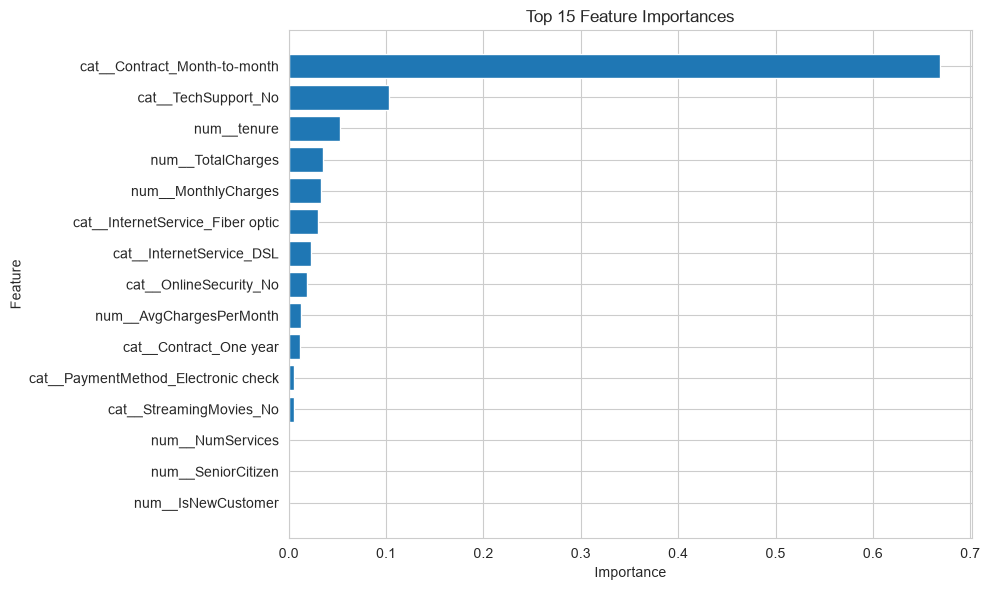

In [53]:
# Feature importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": trained_tree.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

# Plot top 15
top_n = 15
plot_df = importance_df.head(top_n).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [54]:
top5 = importance_df.head(5).copy()
top5["Importance"] = top5["Importance"].round(4)

print("Top 5 drivers of churn prediction:")
for i, row in top5.reset_index(drop=True).iterrows():
    print(f"{i+1}. {row['Feature']} -> {row['Importance']}")

Top 5 drivers of churn prediction:
1. cat__Contract_Month-to-month -> 0.6685
2. cat__TechSupport_No -> 0.1027
3. num__tenure -> 0.0527
4. num__TotalCharges -> 0.0351
5. num__MonthlyCharges -> 0.0336


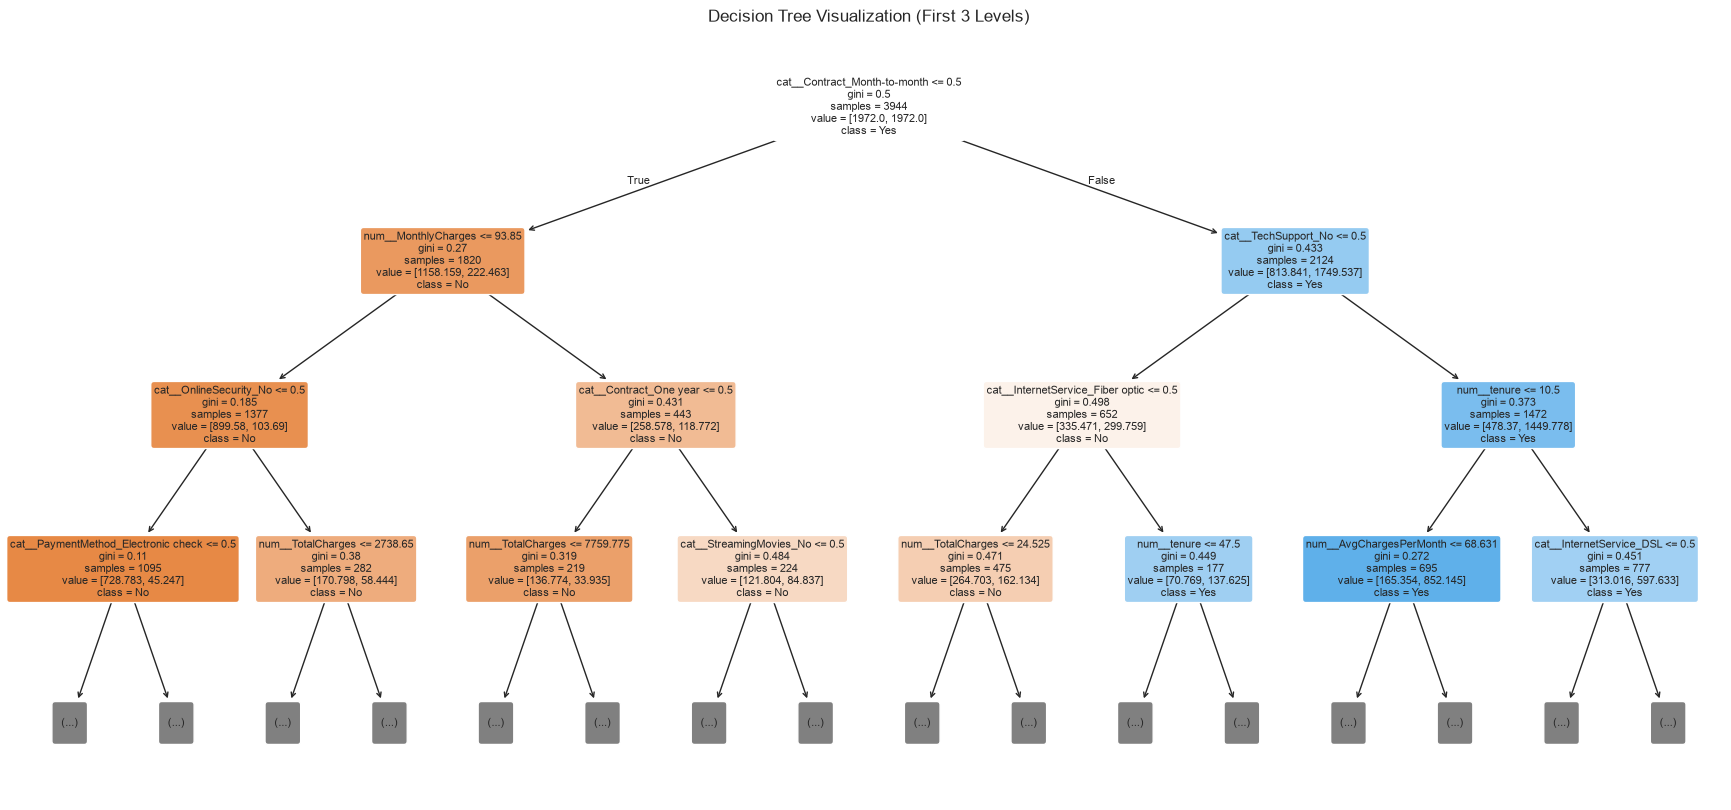

In [55]:
plt.figure(figsize=(22, 10))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=3,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [ ]:
tree_rules = export_text(
    trained_tree,
    feature_names=list(feature_names),
    max_depth=3
)
print(tree_rules)

### Step 6 Interpretation Summary

Key findings:
- The model relies most on a small set of features (shown in top feature importance list).
- Contract type, tenure/charge-related variables, and service-related attributes are key churn drivers.
- The tree structure shows clear split rules that separate high-risk and low-risk customer groups.

Business use:
Customers falling into high-risk branches (based on contract, tenure, and charge/service patterns) can be targeted with retention offers, plan optimization, and support interventions.

Overall interpretation:
The model is mainly driven by contract type, especially month-to-month customers. The next important factors are tech support availability, tenure, and billing-related variables.

## Step 7: Model Saving + API

In this step, we will save the final trained pipeline

In [57]:
import os
import json
import joblib

os.makedirs("../model", exist_ok=True)

# Save full pipeline (preprocessing + model)
joblib.dump(final_model, "../model/churn_model.pkl")

required_fields = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges", "TotalCharges"
]

with open("../model/input_schema.json", "w") as f:
    json.dump({"required_fields": required_fields}, f, indent=2)

print("Saved: ../model/churn_model.pkl")
print("Saved: ../model/input_schema.json")

Saved: ../model/churn_model.pkl
Saved: ../model/input_schema.json


## Final Notes, Buisness Suggestion

For retention action, first target:
- Month-to-month customers
- Customers without tech support
- Lower-tenure customers with higher monthly spend

These groups consistently appeared as high-risk in both EDA and model interpretation.